##### 🏗️ XTALLET CODE
Import Dependencies

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

Create a Simple Graph - allowing the system to dynamically fetch Arxiv papers

Load Arxiv Class

In [10]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
tool_belt = [ArxivQueryRun()]

Load the OpenAI model

In [11]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

Put on the toolbelt

In [12]:
model = model.bind_tools(tool_belt)

Start preparing the Graph

In [13]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage
class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

Create the Graph nodes

In [14]:
from langgraph.prebuilt import ToolNode

def call_model(state):
  messages = state["messages"]
  response = model.invoke(messages)
  return {"messages" : [response]}

tool_node = ToolNode(tool_belt)

Add nodes and set entrypoint

In [15]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

uncompiled_graph.set_entry_point("agent")

Add the conditional edge

In [16]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

Create the last edge and compile the Graph

In [17]:
uncompiled_graph.add_edge("action", "agent")
agent_graph = uncompiled_graph.compile()

Let's try the Graph with an example

In [18]:
from langchain_core.messages import HumanMessage

inputs = {"messages" : [HumanMessage(content="What is the maximum loan amount? Please look at Arxiv for references")]}
async for chunk in agent_graph.astream(inputs, stream_mode="updates"):
    print(f'chunk : {chunk}')
    for node, values in chunk.items():
        print(f'node : {node} and values : {values}')
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

chunk : {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_y36KObWClvnSIiYtV0DeXRxw', 'function': {'arguments': '{"query":"maximum loan amount"}', 'name': 'arxiv'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 110, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': None, 'id': 'chatcmpl-Bsc23rF3dQuEd7TTsNmqGsUw47sUJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c50dd8e5-daf4-4bbd-b039-2a3271e381e5-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'maximum loan amount'}, 'id': 'call_y36KObWClvnSIiYtV0DeXRxw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 110, 'output_tokens': 16, 'total_t

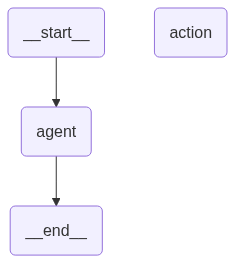

In [20]:
agent_graph

Helper Functions - Wall Imports

In [21]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

Helper Functions - Agent Node Helper

In [22]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

Helper Functions - Agent Creation Helper Function

In [23]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> AgentExecutor:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
    " Do not ask for clarification."
    " Your other team members (and other teams) will collaborate with you with their own specialties."
    " You are chosen for a reason!")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"), # XTALLET - Historial de conversciones
            MessagesPlaceholder(variable_name="agent_scratchpad"), # XTALLET - Espacio de trabajo del agente
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

Helper Functions - Supervisor Helper Function

In [24]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members # XTALLET - Opciones de routing - Ej : ["FINISH", "researcher", "writer", "reviewer"]
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
        | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

Start Preparing the Research Team

In [25]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

Start Preparing the Research Team - Load LLM

In [26]:
llm = ChatOpenAI(model="gpt-4o-mini")

Research Team : Search Agent

In [27]:
arxiv_tool = ArxivQueryRun()
search_agent = create_agent(
    llm,
    [arxiv_tool],
    "You are a research assistant who can search for up-to-date info using the arxiv search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="ArxivSearch")

Research Team : Supervisor

In [28]:
supervisor_agent = create_team_supervisor(
    llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers:  ArxivSearch. Given the following user request,"
    " determine the subject to be researched and respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. "
    " You should never ask your team to do anything beyond research. They are not required to write content or posts."
    " You should only pass tasks to workers that are specifically research focused."
    " When finished, respond with FINISH."),
    ["ArxivSearch"],
)

/tmp/ipykernel_13810/1551680679.py:34: LangChainDeprecationWarning: The method `BaseChatOpenAI.bind_functions` was deprecated in langchain-openai 0.2.1 and will be removed in 1.0.0. Use :meth:`~langchain_openai.chat_models.base.ChatOpenAI.bind_tools` instead.
  | llm.bind_functions(functions=[function_def], function_call="route")


Research Team - Graph Creation

In [29]:
research_graph = StateGraph(ResearchTeamState)

research_graph.add_node("ArxivSearch", search_node)
research_graph.add_node("supervisor", supervisor_agent)

In [30]:
research_graph.add_edge("ArxivSearch", "supervisor")
research_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {"ArxivSearch": "ArxivSearch", "FINISH": END},
)

Set the entrypoint and compile the graph

In [31]:
research_graph.set_entry_point("supervisor")
compiled_research_graph = research_graph.compile()

Display Research Graph

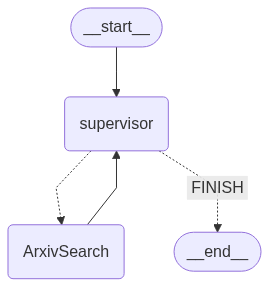

In [32]:
import nest_asyncio
nest_asyncio.apply()

from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_research_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            #draw_method=MermaidDrawMethod.PYPPETEER,
            draw_method=MermaidDrawMethod.API,
            background_color="white",
            padding=10,
        )
    )
)

In [36]:
def enter_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_chain | compiled_research_graph

In [37]:
for s in research_chain.stream(
    "How are large language models being adapted for low-resource languages in natural language processing?", {"recursion_limit": 100}
):
    if "__end__" not in s:
        print(s)
        print("---")

{'supervisor': {'next': 'ArxivSearch'}}
---
{'ArxivSearch': {'messages': [HumanMessage(content='Large language models are being adapted for low-resource languages in various ways, as highlighted in a few recent research papers:\n\n1. **Cedille: A Large Autoregressive French Language Model** - This study explores the development of Cedille, a large open-source autoregressive language model specifically trained for the French language. It showcases that such models can outperform existing language models and provide competitive performance with larger models like GPT-3, particularly in zero-shot benchmarks. The research illustrates that scaling up model size and training can enhance performance, even for languages with fewer resources.\n\n2. **Multilingual Text Classification for Dravidian Languages** - This research addresses the challenges of processing Dravidian languages, which are a significant but under-resourced family of languages. It proposes a multilingual text classification f

Writin Team - Graph Preparation

Tool Creation

In [55]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os
from langchain_core.tools import tool

os.makedirs('./content/advanced_build/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/advanced_build/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

Document Writing State

In [56]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

Document Writing Prelude Function

In [57]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

Document Writing Node Creation

In [58]:
doc_writer_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are a technical writing expert specialized in Machine Learning research.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocWriter"
)

note_taking_agent = create_agent(
    llm,
    [create_outline, read_document, reference_previous_responses],
    ("You are an assistant specializing in research note-taking."
     "Your task is to read the Machine Learning paper and extract detailed"
     "supporting material that can help other agents write summaries and posts.\n{current_files}"),
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="NoteTaker"
)

copy_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are a professional copy editor specializing in LinkedIn content." 
     "Your task is to refine the provided draft text into a well-written," 
     "engaging post appropriate for a professional audience."
     "Make sure the tone is clear, confident, and informative without sounding too academic or promotional.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

empathy_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are an empathy and tone advisor for professional communications." 
     "Your task is to review the refined LinkedIn post and ensure that it feels approachable," 
     "relatable, and aligned with a human-centered tone."
    "Below are files currently in your directory:\n{current_files}"),
)
empathy_editor_agent = prelude | empathy_editor_agent
empathy_node = functools.partial(
    agent_node, agent=empathy_editor_agent, name="EmpathyEditor"
)

doc_writing_supervisor = create_team_supervisor(
    llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: {team_members}. You should always verify the technical"
    " contents after any edits are made. "
    "Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When each team is finished,"
    " you must respond with FINISH."),
    ["DocWriter", "NoteTaker", "EmpathyEditor", "CopyEditor"],
)

Document Writing Team LangGraph Construction

In [59]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("EmpathyEditor", empathy_node)
authoring_graph.add_node("supervisor", doc_writing_supervisor)

authoring_graph.add_edge("DocWriter", "supervisor")
authoring_graph.add_edge("NoteTaker", "supervisor")
authoring_graph.add_edge("CopyEditor", "supervisor")
authoring_graph.add_edge("EmpathyEditor", "supervisor")

authoring_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "CopyEditor" : "CopyEditor",
        "EmpathyEditor" : "EmpathyEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("supervisor")
compiled_authoring_graph = authoring_graph.compile()

Display the Graph

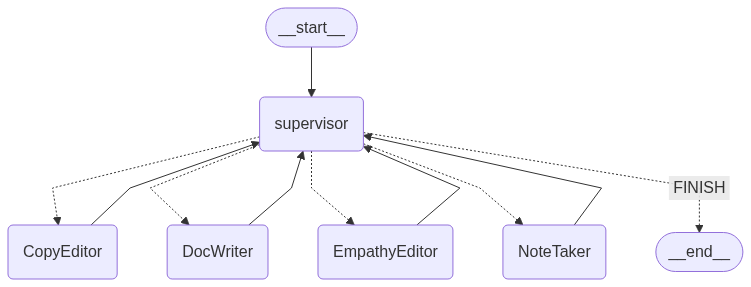

In [60]:
from IPython.display import Image, display

display(
    Image(
        compiled_authoring_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            #draw_method=MermaidDrawMethod.PYPPETEER,
            draw_method=MermaidDrawMethod.API,
            background_color="white",
            padding=10,
        )
    )
)

Create the interface between our Graph and the level above

In [61]:
def enter_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_chain, members=authoring_graph.nodes)
    | authoring_graph.compile()
)

Let's test it

In [48]:
for s in authoring_chain.stream(
    "Write a professional LinkedIn-style post based on a Machine Learning paper that introduces a novel approach to improving model interpretability for non-technical stakeholders.",
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'supervisor': {'next': 'DocWriter'}}
---
{'DocWriter': {'messages': [HumanMessage(content='I have created a professional LinkedIn-style post based on a novel approach to improving model interpretability for non-technical stakeholders. The content has been saved in the file "machine_learning_interpretability_linkedin_post.txt". If you need any modifications or additional information, feel free to ask!', additional_kwargs={}, response_metadata={}, name='DocWriter')]}}
---
{'supervisor': {'next': 'NoteTaker'}}
---
{'NoteTaker': {'messages': [HumanMessage(content='Here is the professional LinkedIn-style post based on the novel approach to improving model interpretability for non-technical stakeholders:\n\n---\n\n🌟 Exciting Development in Machine Learning! 🌟\n\nI’m thrilled to share insights from a recently published paper that introduces a groundbreaking approach to improving model interpretability, specifically designed for non-technical stakeholders.\n\n🔍 **Understanding Model Interpret

Meta-Supervisor and Full Graph

Create the Supervidor Node

In [62]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

supervisor_node = create_team_supervisor(
    llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When all workers are finished,"
    " you must respond with FINISH.",
    ["Research team", "Response team"],
)

Create the State

In [63]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

Create the Super Graph

In [64]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node("Response team", get_last_message | authoring_chain | join_graph)
super_graph.add_node("supervisor", supervisor_node)

Create the edges

In [65]:
super_graph.add_edge("Research team", "supervisor")
super_graph.add_edge("Response team", "supervisor")
super_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "Response team": "Response team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("supervisor")
compiled_super_graph = super_graph.compile()

Display Super Graph

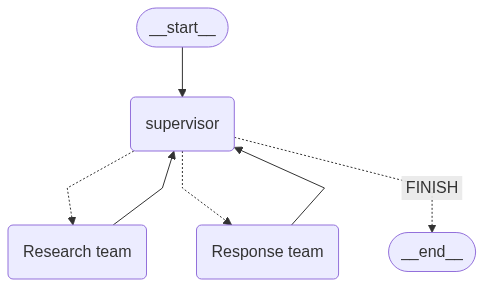

In [66]:
from IPython.display import Image, display

display(
    Image(
        compiled_super_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            #draw_method=MermaidDrawMethod.PYPPETEER,
            draw_method=MermaidDrawMethod.API,
            background_color="white",
            padding=10,
        )
    )
)

Use the full agent

In [67]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Write a LinkedIn post based on a Machine Learning research paper about optimizing transformer models for efficiency in low-resource settings. First consult the research team. Then make sure you consult the response team. Verify factual accuracy and LinkedIn style fit, and write the final version to disk."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'supervisor': {'next': 'Research team'}}
---
{'Research team': {'messages': [HumanMessage(content="Based on my search for up-to-date research on optimizing transformer models for efficiency, I found relevant papers that address the challenges in low-resource settings. Below, I've drafted a LinkedIn post that highlights key insights from a recent study, suitable for sharing on a professional platform:\n\n---\n\n🚀 Exciting advancements in Machine Learning! 🚀\n\nIn a world increasingly reliant on machine learning, especially in natural language processing, the optimization of transformer models for efficiency in low-resource settings has become a critical focus. 🌍✨\n\nA recent study presents a novel approach that emphasizes the significant impact of pre-training transformer models on high-resource data before fine-tuning them for low-resource tasks. This method was shown to enhance performance dramatically—from a BLEU score of just 3.5 to 7.1 in low-resource language translation tasks, e

SAMPLE POST :

🚀 Exciting advancements in Machine Learning! 🚀

In a world increasingly reliant on machine learning, especially in natural language processing, optimizing transformer models for efficiency in low-resource settings has become a critical focus. 🌍✨

A recent study presents a novel approach that emphasizes the significant impact of pre-training transformer models on high-resource data before fine-tuning them for low-resource tasks. This method was shown to enhance performance dramatically—from a BLEU score of just 3.5 to 7.1 in low-resource language translation tasks, exemplifying the power of transferable knowledge.

💡 Key takeaways from the research:
1. **Transfer Learning**: Pre-training on abundant data can drastically improve accuracy in low-data scenarios.
2. **Cross-linguistic Benefits**: Interestingly, pre-training on languages different from the task at hand still yielded notable improvements, suggesting a shared learning mechanism in transformers.
3. **Efficiency Innovations**: Continued work in optimizing dataflow mapping in transformer architectures promises to boost computational efficiency, making advanced language processing accessible even in resource-constrained environments.

These advancements are paving the way for more inclusive AI technologies that cater to diverse linguistic needs. As we strive for global understanding, it's essential to leverage every bit of knowledge to bridge the gaps.

Let's harness the power of AI to create a future where language barriers are a thing of the past! 🤝🌐

#MachineLearning #AI #Transformers #NaturalLanguageProcessing #Research #DataScience #Inclusion #Innovation